In [9]:
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import umap
import plotly.io as pio

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
## FUNCTIONS

def plot_umap(
    data, 
    target=None,
    n_neighbors=15, 
    min_dist=0.1, 
    n_components=2, 
    metric='euclidean', 
    title=''
    ): 
    
    # construct model
    reducer = umap.UMAP(
        random_state=42, 
        n_components=n_components, 
        n_neighbors=n_neighbors,
        metric=metric)
    
    # train model 
    reducer.fit(data)
    
    # to access the resulting transform, we inspect `embedding_` attribute
    # or call transform on the original data
    embedding = reducer.transform(data)
#     embedding = reducer.fit_transform(data);
    
    # now plot the resulting embedding, coloring the data points by the class that they belong to
    fig = plt.figure()
    if n_components == 1:
        ax = fig.add_subplot(111)
        ax.scatter(embedding[:, 0], range(len(embedding)), c=target, cmap='Spectral', s=5)
    if n_components == 2:
        ax = fig.add_subplot(111)
        ax.scatter(embedding[:, 0], embedding[:, 1], c=target, cmap='Spectral', s=5)
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(embedding[:, 0], embedding[:, 1], c=target, cmap='Spectral', s=5)
    
    plt.title(title, fontsize=18)
    plt.gca().set_aspect('equal', 'datalim')
#     if target is not None:
#         plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))

## MNIST Example

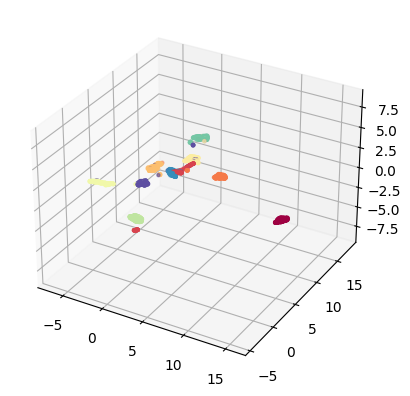

In [34]:
from sklearn.datasets import load_digits

digits = load_digits()

digits_df = pd.DataFrame(digits.data[:,1:11])
digits_df['digit'] = pd.Series(digits.target).map(lambda x: 'Digit {}'.format(x))

plot_umap(data=digits.data, target=digits.target, n_components=3) 

## HBN

In [154]:
df

,Identifiers,"PreInt_Demos_Fam,Child_Ethnicity","PreInt_Demos_Fam,Child_Race","PreInt_Demos_Fam,DP_Yrs","PreInt_Demos_Fam,Days_Baseline","PreInt_Demos_Fam,Divorced_Yrs","PreInt_Demos_Fam,Married_Yrs","PreInt_Demos_Fam,No_P2","PreInt_Demos_Fam,P1_Age","PreInt_Demos_Fam,P1_Ethnicity",...,"PreInt_TxHx,lost_consciousness","PreInt_TxHx,med_allergy","PreInt_TxHx,number_injuries","PreInt_TxHx,other_med_cur","PreInt_TxHx,other_med_past","PreInt_TxHx,psych_meds_cur","PreInt_TxHx,psych_meds_past","PreInt_TxHx,serious_injury","PreInt_TxHx,suicide","PreInt_TxHx,trauma"
0,NDARBM433VER,0.0,0.0,NaN,93.0,3.0,NaN,NaN,45.0,0.0,...,NaN,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
1,NDARCM811CV1,2.0,9.0,NaN,114.0,NaN,NaN,1.0,39.0,2.0,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NDARCP292KPA,0.0,NaN,NaN,117.0,NaN,24.0,NaN,50.0,0.0,...,NaN,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,NDARDX770PJK,0.0,0.0,NaN,0.0,NaN,22.0,NaN,45.0,0.0,...,NaN,1.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,1.0
4,NDARHL164JHH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,NDARYZ433UL5,0.0,0.0,NaN,41.0,NaN,NaN,NaN,44.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,NaN
1315,NDARZL162HZH,NaN,0.0,NaN,29.0,NaN,NaN,1.0,53.0,0.0,...,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1316,NDARZX667AT5,0.0,0.0,NaN,44.0,NaN,NaN,NaN,49.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1317,NDARFX721WR8,1.0,0.0,NaN,29.0,NaN,NaN,NaN,49.0,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [172]:
import os
from hbn.features import build_features 
from hbn.data import make_dataset
from hbn.constants import Defaults

# get features
df = build_features.get_features(
    assessment='Parent Measures',
    domains=['Interview of Emotional and Psychological Function'],
    measures=['Intake Interview'],
    min_num_participants=2000,
);

# load participants and filter
adhd = pd.read_csv(os.path.join(Defaults.MODEL_SPEC_DIR, 'train_participants-ADHD.csv'))
learning = pd.read_csv(os.path.join(Defaults.MODEL_SPEC_DIR, 'train_participants-Specific_Learning_Disorder_with_Impairment_in_Reading.csv'))
no_diagnosis = pd.read_csv(os.path.join(Defaults.MODEL_SPEC_DIR, 'train_participants-No_Diagnosis_Given.csv'))

df = df.merge(pd.concat([no_diagnosis, adhd, learning]), on=['Identifiers'])

# get numeric data
numeric_data = df.select_dtypes(include='number')

df = pd.concat([df[['Identifiers']], numeric_data], axis=1)


reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Interview_of_Emotional_and_Psychological_Function/Intake_Interview.csv into dataframe


In [173]:
df

,Identifiers,"PreInt_Demos_Fam,Child_Ethnicity","PreInt_Demos_Fam,Child_Race","PreInt_Demos_Fam,DP_Yrs","PreInt_Demos_Fam,Days_Baseline","PreInt_Demos_Fam,Divorced_Yrs","PreInt_Demos_Fam,Married_Yrs","PreInt_Demos_Fam,No_P2","PreInt_Demos_Fam,P1_Age","PreInt_Demos_Fam,P1_Ethnicity",...,"PreInt_TxHx,lost_consciousness","PreInt_TxHx,med_allergy","PreInt_TxHx,number_injuries","PreInt_TxHx,other_med_cur","PreInt_TxHx,other_med_past","PreInt_TxHx,psych_meds_cur","PreInt_TxHx,psych_meds_past","PreInt_TxHx,serious_injury","PreInt_TxHx,suicide","PreInt_TxHx,trauma"
0,NDARBM433VER,0.0,0.0,NaN,93.0,3.0,NaN,NaN,45.0,0.0,...,NaN,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
1,NDARCD401HGZ,NaN,NaN,NaN,0.0,NaN,26.0,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,NDARCM811CV1,2.0,9.0,NaN,114.0,NaN,NaN,1.0,39.0,2.0,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NDARCP292KPA,0.0,NaN,NaN,117.0,NaN,24.0,NaN,50.0,0.0,...,NaN,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,NDARDX770PJK,0.0,0.0,NaN,0.0,NaN,22.0,NaN,45.0,0.0,...,NaN,1.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1767,NDARYZ433UL5,0.0,0.0,NaN,41.0,NaN,NaN,NaN,44.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,NaN
1768,NDARZL162HZH,NaN,0.0,NaN,29.0,NaN,NaN,1.0,53.0,0.0,...,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1769,NDARZX667AT5,0.0,0.0,NaN,44.0,NaN,NaN,NaN,49.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1770,NDARFX721WR8,1.0,0.0,NaN,29.0,NaN,NaN,NaN,49.0,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [ ]:
# preprocess the data
clf_info = {
        "numeric": [
            [
                "sklearn.impute",
                "SimpleImputer",
                {
                    "strategy": "mean"
                }
            ],
            [
                "sklearn.preprocessing",
                "StandardScaler",
                {}
            ]
        ]
    }

# preprocess
df_preprocessed = build_features.column_transform(
                    dataframe=df,
                    clf_info=clf_info,
                    cols_to_ignore=['Identifiers'])

In [160]:
# get target
dx = make_dataset.make_summary(save=False)

target = dx.merge(participants, on='Identifiers')
labels, names = target['DX_01_Cat_new'].factorize()


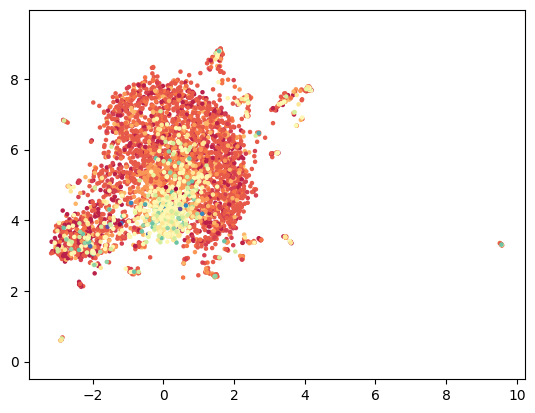

In [135]:
plot_umap(data=np.array(df_preprocessed.drop(["Identifiers"], axis=1)), target=labels, n_components=2) 

In [136]:
df_preprocessed

,Identifiers,"numeric__PreInt_Demos_Fam,Child_Ethnicity","numeric__PreInt_Demos_Fam,Child_Race","numeric__PreInt_Demos_Fam,DP_Yrs","numeric__PreInt_Demos_Fam,Days_Baseline","numeric__PreInt_Demos_Fam,Divorced_Yrs","numeric__PreInt_Demos_Fam,Married_Yrs","numeric__PreInt_Demos_Fam,No_P2","numeric__PreInt_Demos_Fam,P1_Age","numeric__PreInt_Demos_Fam,P1_Ethnicity",...,"numeric__PreInt_TxHx,lost_consciousness","numeric__PreInt_TxHx,med_allergy","numeric__PreInt_TxHx,number_injuries","numeric__PreInt_TxHx,other_med_cur","numeric__PreInt_TxHx,other_med_past","numeric__PreInt_TxHx,psych_meds_cur","numeric__PreInt_TxHx,psych_meds_past","numeric__PreInt_TxHx,serious_injury","numeric__PreInt_TxHx,suicide","numeric__PreInt_TxHx,trauma"
0,NDARAT581NDH,0.000000,-1.509525e-16,-3.314495e-15,2.976646e-16,0.000000,0.000000,0.0,0.000000,-9.823320e-17,...,0.000000,-0.302826,0.000000,-4.881945e-01,-0.275921,-0.506410,2.460621e+00,-0.453550,3.357891,2.751211
1,NDARBE439ND3,0.000000,-1.509525e-16,-3.314495e-15,-1.038730e+00,0.000000,5.409854,0.0,0.000000,-9.823320e-17,...,0.000000,3.356708,0.000000,-7.695286e-17,0.000000,0.000000,8.088906e-17,-0.453550,3.357891,-0.379921
2,NDARBF851NH6,0.000000,-1.509525e-16,-3.314495e-15,-4.522345e-01,-0.753772,0.000000,0.0,1.333909,1.219538e+00,...,-0.361367,-0.302826,0.000000,-4.881945e-01,-0.275921,-0.506410,2.460621e+00,-0.453550,-0.311440,-0.379921
3,NDARBM433VER,-0.646724,-6.941709e-01,-3.314495e-15,9.092741e-01,-0.847371,0.000000,0.0,0.213963,-5.500746e-01,...,0.000000,-0.302826,-1.211395,-4.881945e-01,-0.275921,2.203367,2.460621e+00,2.243452,-0.311440,-0.379921
4,NDARCD401HGZ,0.000000,-1.509525e-16,-3.314495e-15,-1.038730e+00,0.000000,2.586512,0.0,0.000000,-9.823320e-17,...,-0.361367,-0.302826,0.000000,-7.695286e-17,0.000000,0.000000,8.088906e-17,-0.453550,-0.311440,-0.379921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4061,NDARZR480CR5,-0.646724,-6.941709e-01,-3.314495e-15,-4.731808e-01,0.000000,0.000000,0.0,0.773936,-5.500746e-01,...,-0.361367,-0.302826,0.000000,-4.881945e-01,-0.275921,-0.506410,-4.537145e-01,-0.453550,-0.311440,-0.379921
4062,NDARBE680TCD,0.000000,-1.509525e-16,-3.314495e-15,2.976646e-16,0.000000,0.000000,0.0,0.000000,-9.823320e-17,...,-0.361367,-0.302826,0.000000,-4.881945e-01,-0.275921,-0.506410,-4.537145e-01,-0.453550,-0.311440,-0.379921
4063,NDARDD198WAZ,-0.646724,2.025148e+00,-3.314495e-15,-1.038730e+00,0.000000,1.066250,0.0,1.333909,-5.500746e-01,...,0.000000,-0.302826,0.000000,-4.881945e-01,-0.275921,-0.506410,-4.537145e-01,-0.453550,-0.311440,-0.379921
4064,NDARNJ687DMC,-0.646724,-6.941709e-01,-3.314495e-15,-1.038730e+00,0.000000,-0.671191,0.0,6.093679,-5.500746e-01,...,0.000000,-0.302826,0.000000,-7.695286e-17,0.000000,0.000000,8.088906e-17,-0.453550,0.000000,0.000000
